# Plot DeepMD vs DFT correlation metrics

This notebook reads the text files written by `02_dp_inference.ipynb` and produces parity plots,
error histograms, text reports, and cross-model comparison tables.


In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [14]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "model_analysis" else Path.cwd().resolve()

INFERENCE_ROOT = PROJECT_ROOT / "model_analysis" / "outputs" / "inference"
INFERENCE_PATTERN = "*"  # Selects the per-model inference subdirectories to include.
STYLE_FILE = None  # Optional matplotlib style file applied to all plots.
N_ATOMS = None  # If None, infer the atom count from the force-level data.
REPORT_DIR = PROJECT_ROOT / "model_analysis" / "outputs" / "correlation_reports"


In [15]:
if STYLE_FILE is not None:
    plt.style.use(STYLE_FILE)

def stats(y_true, y_pred):
    diff = np.asarray(y_pred) - np.asarray(y_true)
    mae = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff ** 2))
    r2 = 1.0 - np.sum(diff ** 2) / np.sum((y_true - np.mean(y_true)) ** 2) if len(y_true) > 1 else np.nan
    return mae, rmse, r2

run_data = {}
for run_dir in sorted(path for path in INFERENCE_ROOT.glob(INFERENCE_PATTERN) if path.is_dir()):
    energy_file = run_dir / "energies_forces.txt"
    atom_file = run_dir / "energies_forces_atoms.txt"
    if not energy_file.exists() or not atom_file.exists():
        continue
    energy_df = pd.read_csv(energy_file, comment="#", sep=r"\s+", names=["frame", "energy_DFT_eV", "energy_DP_eV"], engine="python")
    atom_df = pd.read_csv(atom_file, comment="#", sep=r"\s+", names=["frame", "atom", "element", "fx_DFT", "fy_DFT", "fz_DFT", "fx_DP", "fy_DP", "fz_DP", "energy_DFT", "energy_DP"], engine="python")
    run_data[run_dir.name] = {"energy": energy_df.dropna().reset_index(drop=True), "atom": atom_df.dropna().reset_index(drop=True)}

if not run_data:
    raise FileNotFoundError("No complete inference outputs were found.")


## Cross-model summary


In [16]:
summary_rows = []
for label, tables in run_data.items():
    energy_df = tables["energy"]
    atom_df = tables["atom"]
    y_true = energy_df["energy_DFT_eV"].to_numpy(float)
    y_pred = energy_df["energy_DP_eV"].to_numpy(float)
    mae_e, rmse_e, r2_e = stats(y_true, y_pred)
    force_ref = np.sqrt(atom_df["fx_DFT"] ** 2 + atom_df["fy_DFT"] ** 2 + atom_df["fz_DFT"] ** 2).to_numpy(float)
    force_dp = np.sqrt(atom_df["fx_DP"] ** 2 + atom_df["fy_DP"] ** 2 + atom_df["fz_DP"] ** 2).to_numpy(float)
    mae_f, rmse_f, r2_f = stats(force_ref, force_dp)
    summary_rows.append({"model": label, "n_frames": len(energy_df), "energy_rmse_eV": rmse_e, "energy_r2": r2_e, "force_rmse_eVA": rmse_f, "force_r2": r2_f})
summary_df = pd.DataFrame(summary_rows).sort_values("energy_rmse_eV").reset_index(drop=True)
summary_df


,model,n_frames,energy_rmse_eV,energy_r2,force_rmse_eVA,force_r2
0,graph.004.pb,2000,0.020939,0.999514,0.016372,0.999696
1,graph.003.pb,2000,0.023590,0.999383,0.016793,0.999680
2,graph.002.pb,2000,0.026271,0.999235,0.016522,0.999691
3,graph.001.pb,2000,0.028625,0.999092,0.017819,0.999640


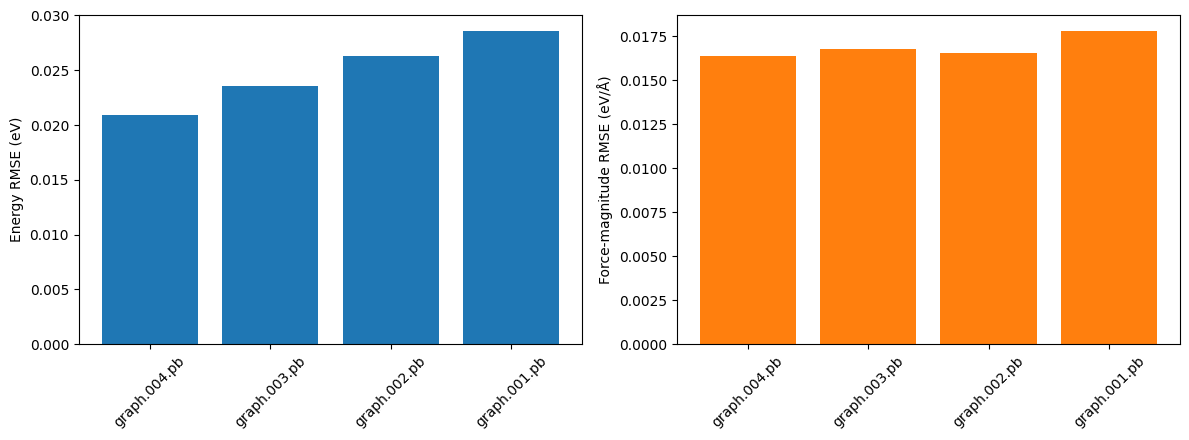

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(summary_df["model"], summary_df["energy_rmse_eV"], color="tab:blue")
axes[0].set_ylabel("Energy RMSE (eV)")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(summary_df["model"], summary_df["force_rmse_eVA"], color="tab:orange")
axes[1].set_ylabel("Force-magnitude RMSE (eV/Å)")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


## Panel diagnostics

Each diagnostic below is shown as a panel grid so several trainings can be compared directly on the same notebook page.


Saved /Users/samuel/Desktop/postdoc_PhLAM/codes/deepmd_toolkit/model_analysis/outputs/correlation_reports/graph.001.pb_dp_vs_dft_stats.txt
Saved /Users/samuel/Desktop/postdoc_PhLAM/codes/deepmd_toolkit/model_analysis/outputs/correlation_reports/graph.002.pb_dp_vs_dft_stats.txt
Saved /Users/samuel/Desktop/postdoc_PhLAM/codes/deepmd_toolkit/model_analysis/outputs/correlation_reports/graph.003.pb_dp_vs_dft_stats.txt
Saved /Users/samuel/Desktop/postdoc_PhLAM/codes/deepmd_toolkit/model_analysis/outputs/correlation_reports/graph.004.pb_dp_vs_dft_stats.txt


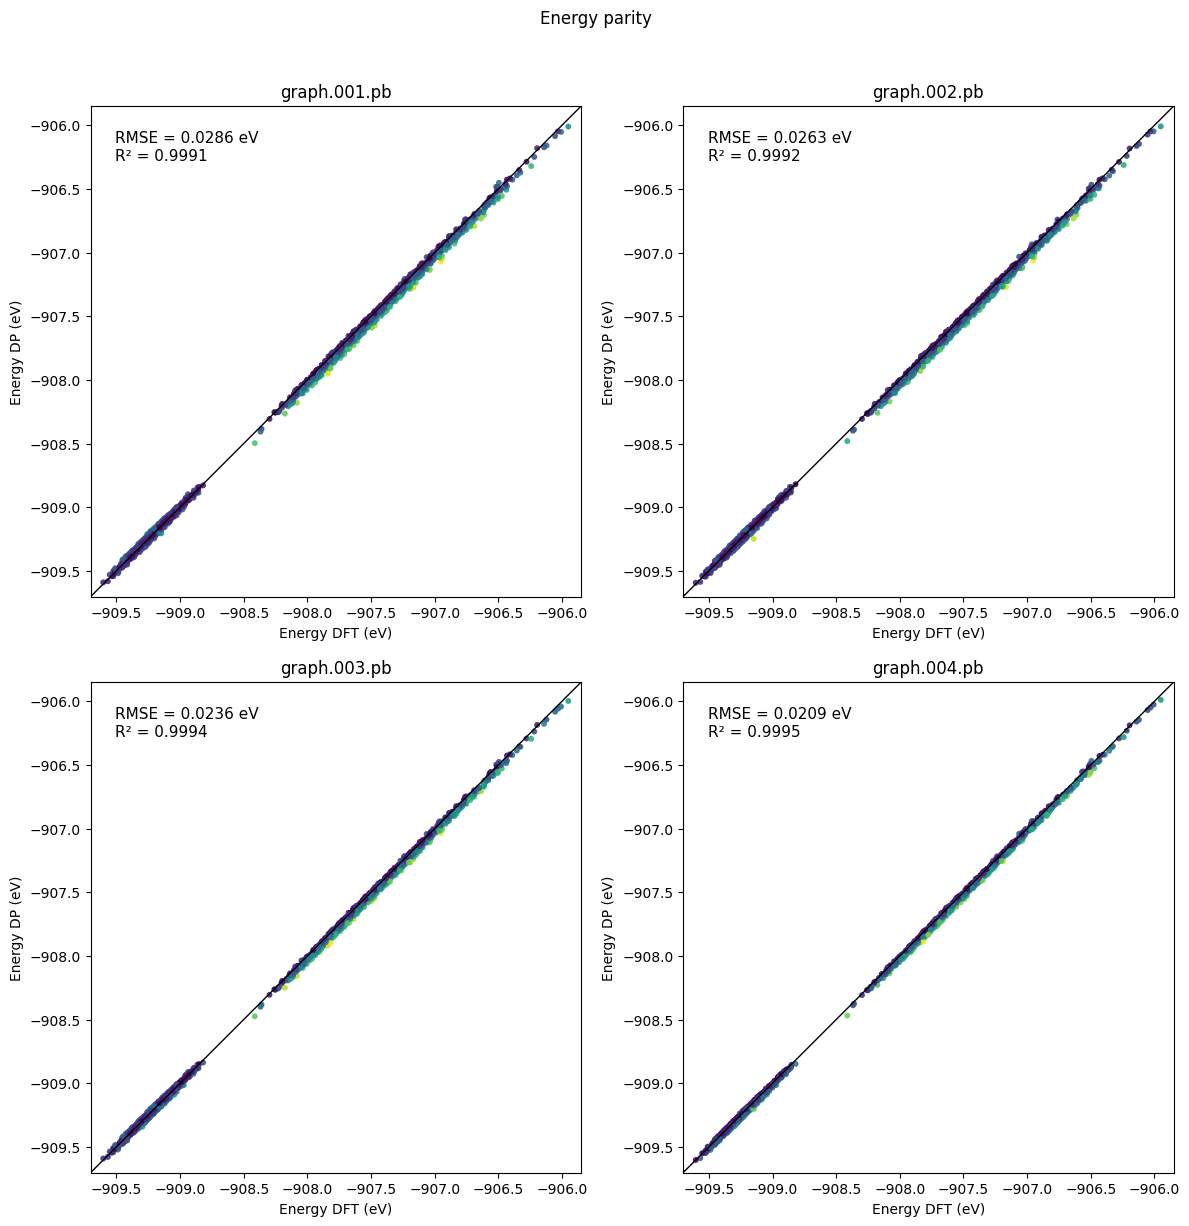

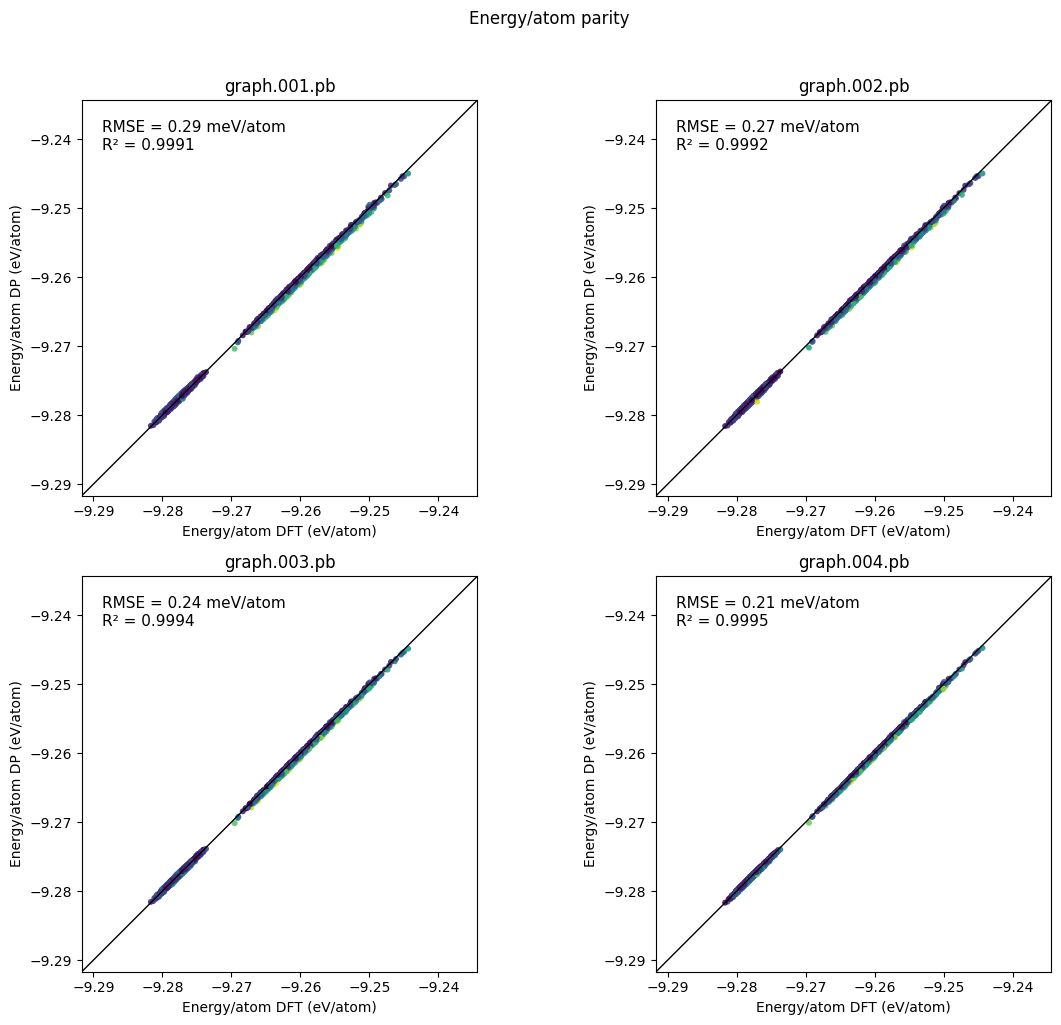

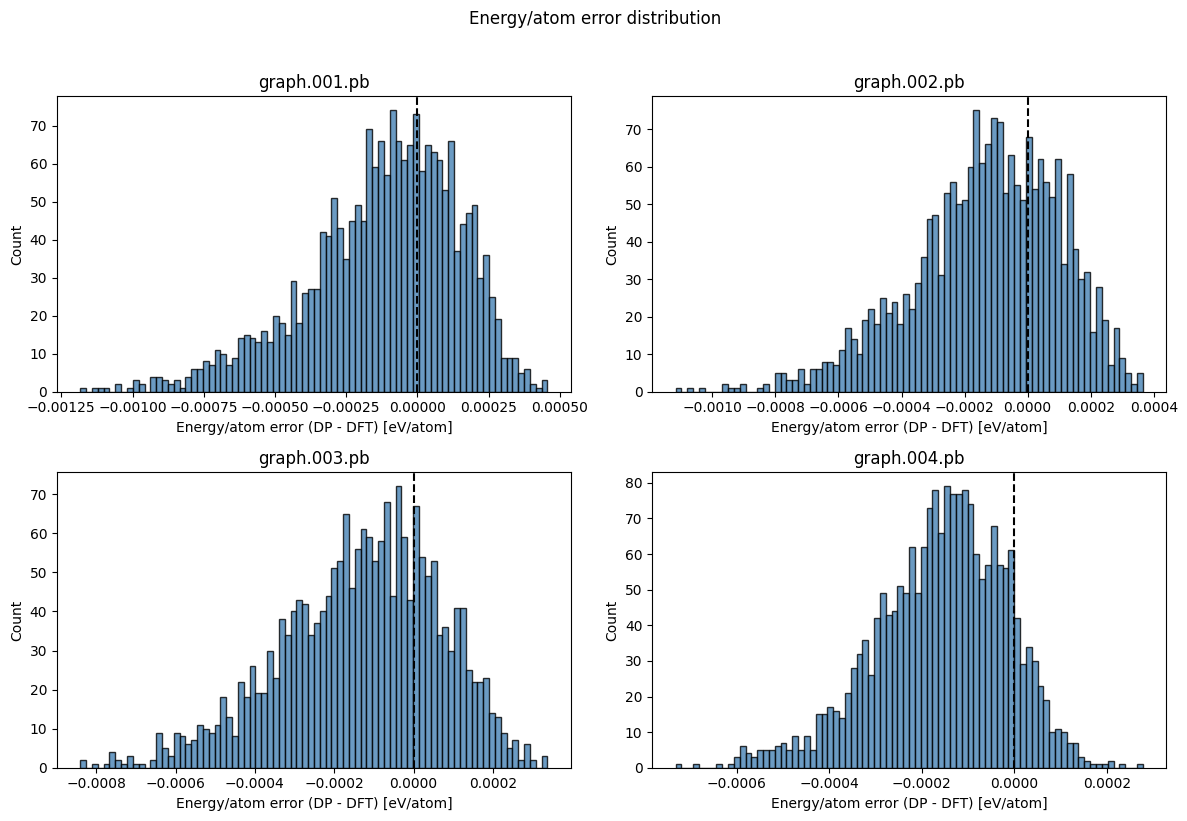

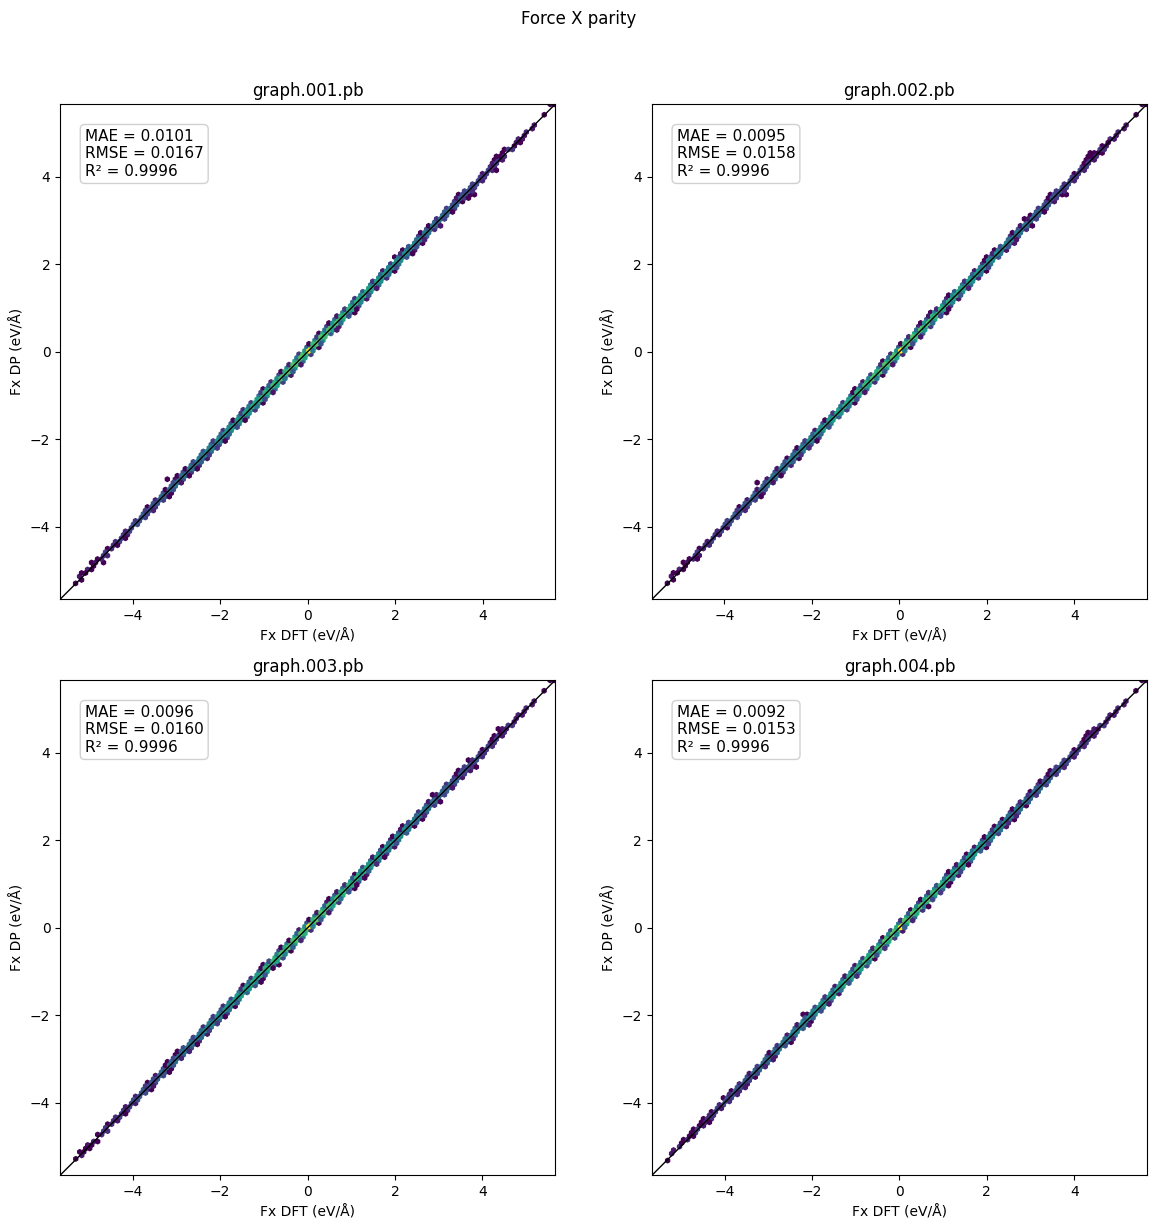

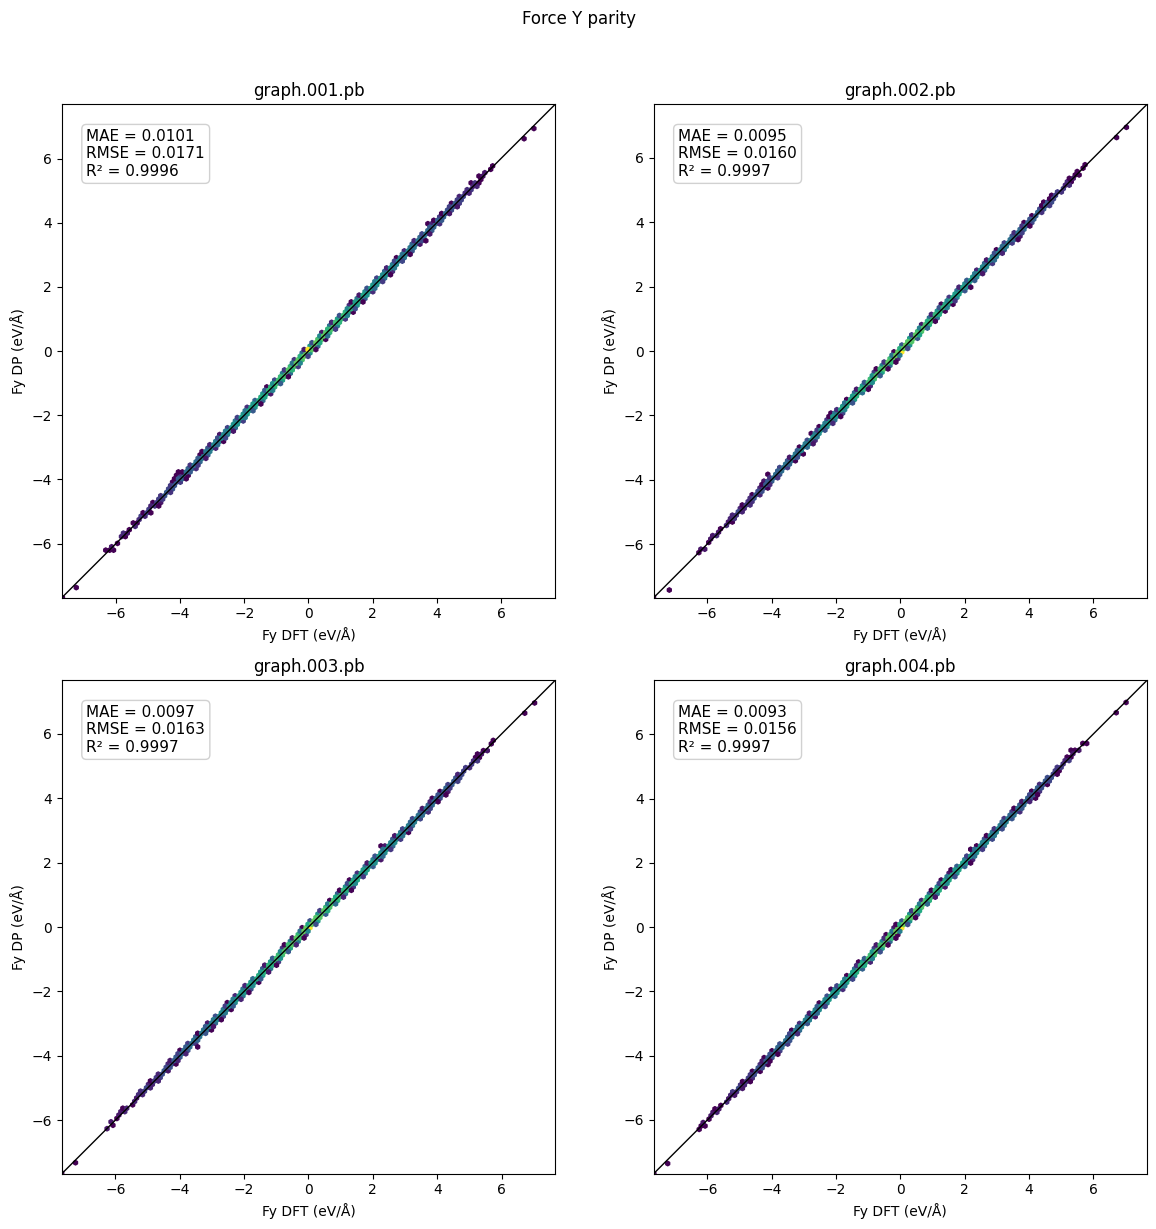

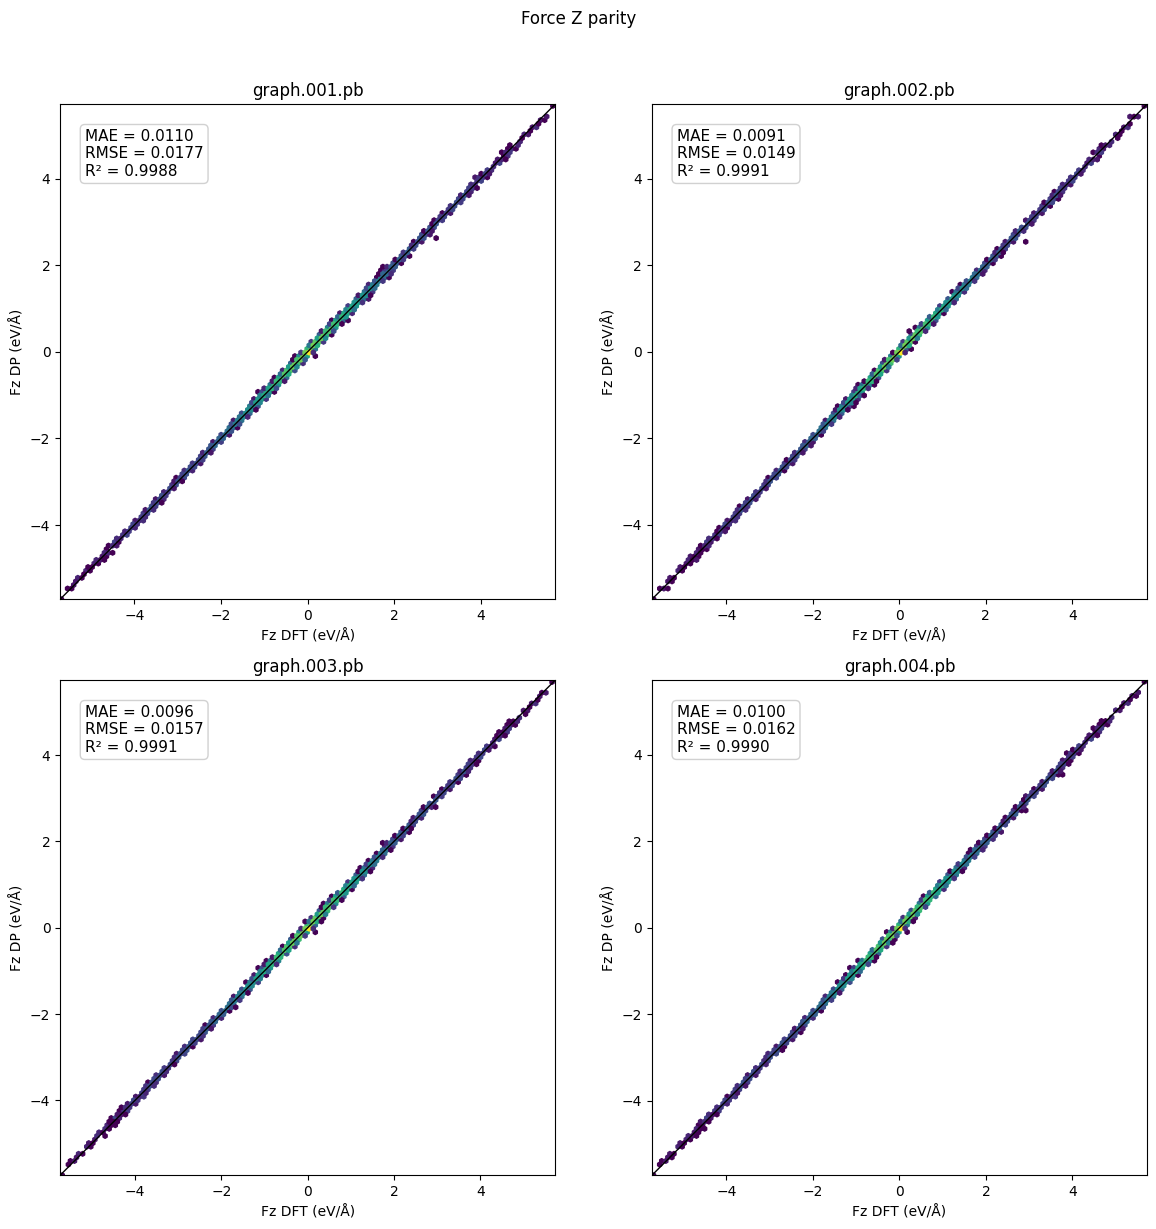

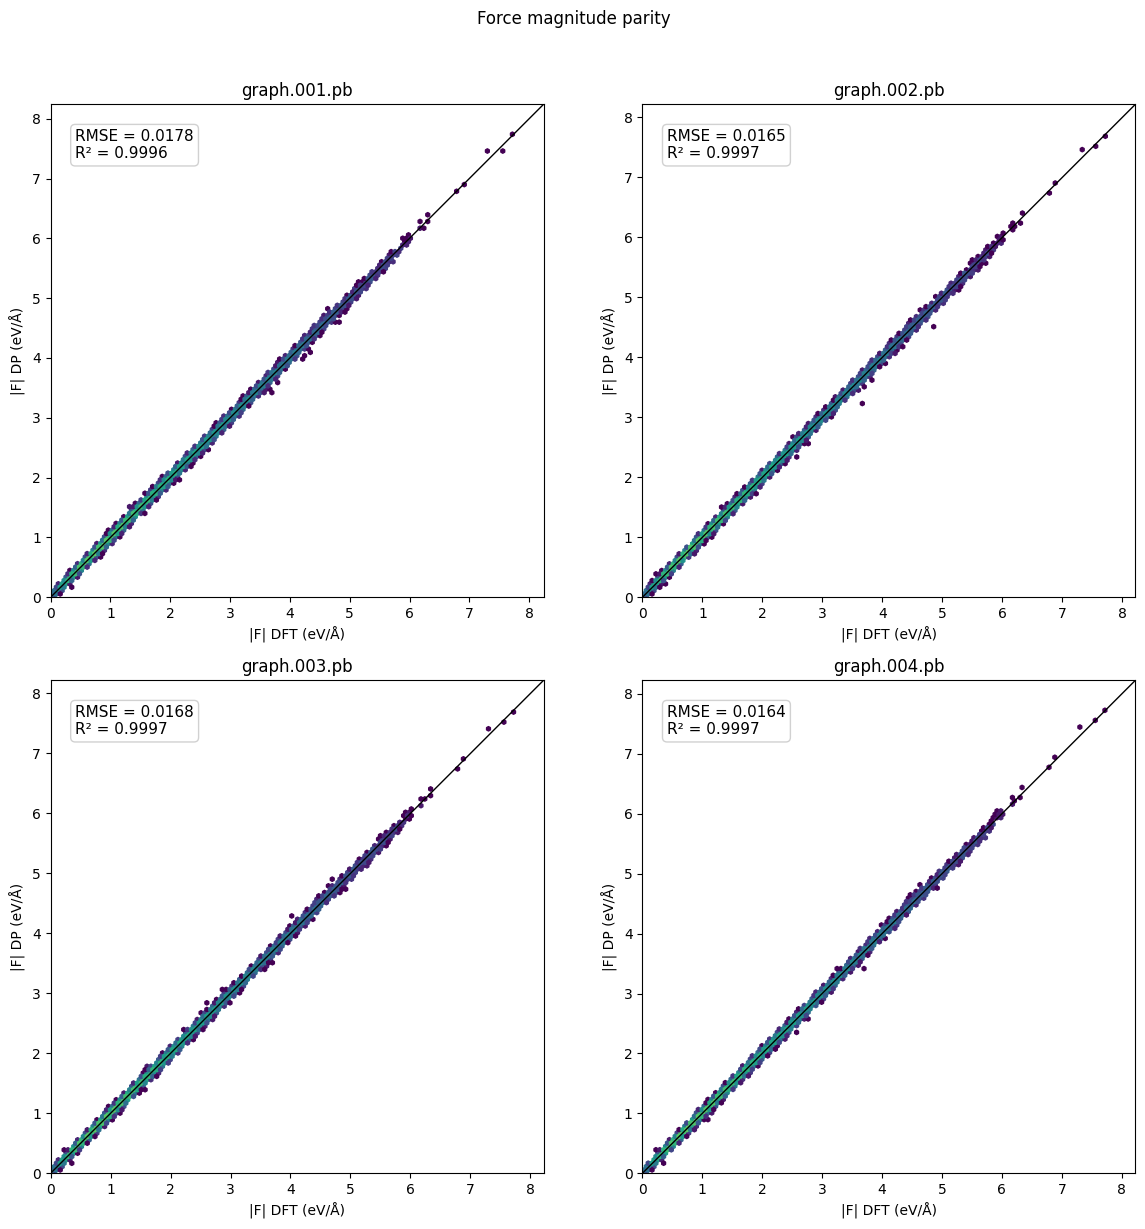

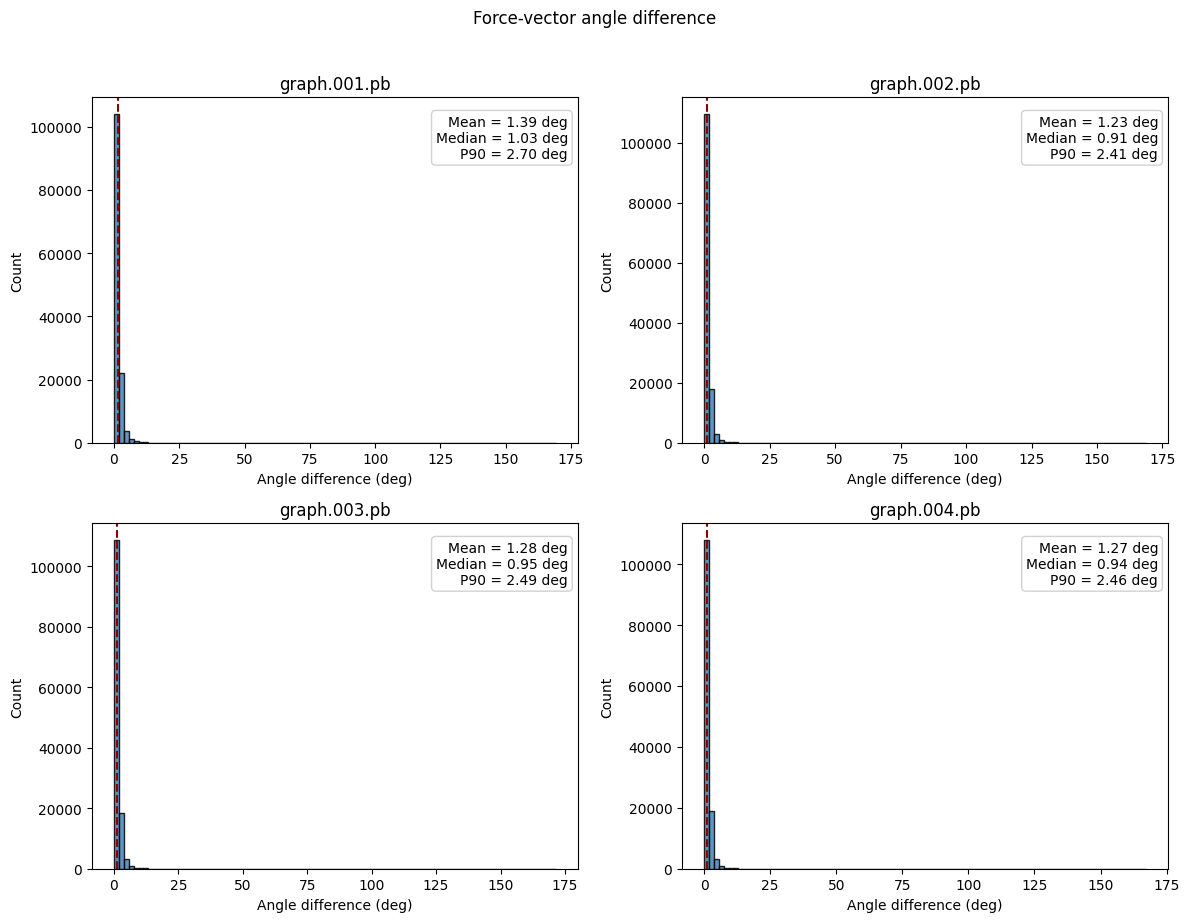

In [18]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)

labels = list(run_data)
n_models = len(labels)
ncols = min(2, max(1, n_models))
nrows = int(np.ceil(n_models / ncols))


def make_panel_axes(figsize_per_panel=(6, 5)):
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,
    )
    return fig, axes.ravel()


def hide_unused_axes(axes, used_count):
    for ax in axes[used_count:]:
        ax.axis("off")


def angle_difference_deg(atom_df):
    force_ref_vectors = atom_df[["fx_DFT", "fy_DFT", "fz_DFT"]].to_numpy(float)
    force_dp_vectors = atom_df[["fx_DP", "fy_DP", "fz_DP"]].to_numpy(float)
    norm_ref = np.linalg.norm(force_ref_vectors, axis=1)
    norm_dp = np.linalg.norm(force_dp_vectors, axis=1)
    mask = (norm_ref > 1e-12) & (norm_dp > 1e-12)
    force_ref_vectors = force_ref_vectors[mask]
    force_dp_vectors = force_dp_vectors[mask]
    norm_ref = norm_ref[mask]
    norm_dp = norm_dp[mask]
    cosine = np.sum(force_ref_vectors * force_dp_vectors, axis=1) / (norm_ref * norm_dp)
    cosine = np.clip(cosine, -1.0, 1.0)
    return np.degrees(np.arccos(cosine))


panel_cache = {}
for label, tables in run_data.items():
    energy_df = tables["energy"]
    atom_df = tables["atom"]

    energy_ref = energy_df["energy_DFT_eV"].to_numpy(float)
    energy_dp = energy_df["energy_DP_eV"].to_numpy(float)
    energy_mae, energy_rmse, energy_r2 = stats(energy_ref, energy_dp)

    if N_ATOMS is None:
        atom_counts = atom_df.groupby("frame").size().reindex(energy_df["frame"]).to_numpy(dtype=float)
    else:
        atom_counts = np.full(len(energy_df), float(N_ATOMS))
    atom_count_mask = np.isfinite(atom_counts) & (atom_counts > 0)
    energy_ref_pa = energy_ref[atom_count_mask] / atom_counts[atom_count_mask]
    energy_dp_pa = energy_dp[atom_count_mask] / atom_counts[atom_count_mask]
    energy_err_pa = energy_dp_pa - energy_ref_pa
    energy_mae_pa, energy_rmse_pa, energy_r2_pa = stats(energy_ref_pa, energy_dp_pa)

    force_ref_x = atom_df["fx_DFT"].to_numpy(float)
    force_dp_x = atom_df["fx_DP"].to_numpy(float)
    force_ref_y = atom_df["fy_DFT"].to_numpy(float)
    force_dp_y = atom_df["fy_DP"].to_numpy(float)
    force_ref_z = atom_df["fz_DFT"].to_numpy(float)
    force_dp_z = atom_df["fz_DP"].to_numpy(float)
    force_ref_mag = np.sqrt(force_ref_x ** 2 + force_ref_y ** 2 + force_ref_z ** 2)
    force_dp_mag = np.sqrt(force_dp_x ** 2 + force_dp_y ** 2 + force_dp_z ** 2)
    force_mae, force_rmse, force_r2 = stats(force_ref_mag, force_dp_mag)
    angle_deg = angle_difference_deg(atom_df)

    panel_cache[label] = {
        "energy_ref": energy_ref,
        "energy_dp": energy_dp,
        "energy_rmse": energy_rmse,
        "energy_r2": energy_r2,
        "energy_ref_pa": energy_ref_pa,
        "energy_dp_pa": energy_dp_pa,
        "energy_err_pa": energy_err_pa,
        "energy_rmse_pa": energy_rmse_pa,
        "energy_r2_pa": energy_r2_pa,
        "force_ref_x": force_ref_x,
        "force_dp_x": force_dp_x,
        "force_ref_y": force_ref_y,
        "force_dp_y": force_dp_y,
        "force_ref_z": force_ref_z,
        "force_dp_z": force_dp_z,
        "force_ref_mag": force_ref_mag,
        "force_dp_mag": force_dp_mag,
        "force_rmse": force_rmse,
        "force_r2": force_r2,
        "angle_deg": angle_deg,
        "atom_df": atom_df,
    }

    report_file = REPORT_DIR / f"{label}_dp_vs_dft_stats.txt"
    with report_file.open("w", encoding="utf-8") as handle:
        handle.write(f"Model: {label}\n")
        handle.write(f"Energy MAE (eV): {energy_mae:.6f}\n")
        handle.write(f"Energy RMSE (eV): {energy_rmse:.6f}\n")
        handle.write(f"Energy R2: {energy_r2:.6f}\n")
        handle.write(f"Energy/atom MAE (eV/atom): {energy_mae_pa:.6f}\n")
        handle.write(f"Energy/atom RMSE (eV/atom): {energy_rmse_pa:.6f}\n")
        handle.write(f"Energy/atom R2: {energy_r2_pa:.6f}\n")
        for component in ["x", "y", "z"]:
            ref = atom_df[f"f{component}_DFT"].to_numpy(float)
            pred = atom_df[f"f{component}_DP"].to_numpy(float)
            mae_c, rmse_c, r2_c = stats(ref, pred)
            handle.write(f"Force {component.upper()} MAE (eV/A): {mae_c:.6f}\n")
            handle.write(f"Force {component.upper()} RMSE (eV/A): {rmse_c:.6f}\n")
            handle.write(f"Force {component.upper()} R2: {r2_c:.6f}\n")
        handle.write(f"Force magnitude MAE (eV/A): {force_mae:.6f}\n")
        handle.write(f"Force magnitude RMSE (eV/A): {force_rmse:.6f}\n")
        handle.write(f"Force magnitude R2: {force_r2:.6f}\n")
        handle.write(f"Force angle mean (deg): {angle_deg.mean():.6f}\n")
        handle.write(f"Force angle median (deg): {np.median(angle_deg):.6f}\n")
        handle.write(f"Force angle P90 (deg): {np.percentile(angle_deg, 90):.6f}\n")
    print(f"Saved {report_file}")


fig, axes = make_panel_axes(figsize_per_panel=(6, 6))
for ax, label in zip(axes, labels):
    values = panel_cache[label]
    y_true = values["energy_ref"]
    y_pred = values["energy_dp"]
    abs_err = np.abs(y_pred - y_true)
    lims = [min(y_true.min(), y_pred.min()) - 0.1, max(y_true.max(), y_pred.max()) + 0.1]
    ax.scatter(y_true, y_pred, c=abs_err, s=18, cmap="viridis", alpha=0.9, edgecolors="none")
    ax.plot(lims, lims, color="black", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Energy DFT (eV)")
    ax.set_ylabel("Energy DP (eV)")
    ax.set_title(label)
    ax.text(0.05, 0.95, f"RMSE = {values['energy_rmse']:.4f} eV\nR² = {values['energy_r2']:.4f}", transform=ax.transAxes, va="top", fontsize=11)
hide_unused_axes(axes, n_models)
fig.suptitle("Energy parity", y=1.02)
fig.tight_layout()
plt.show()

fig, axes = make_panel_axes(figsize_per_panel=(6, 5))
for ax, label in zip(axes, labels):
    values = panel_cache[label]
    y_true = values["energy_ref_pa"]
    y_pred = values["energy_dp_pa"]
    abs_err = np.abs(y_pred - y_true) * 1000.0
    lims = [min(y_true.min(), y_pred.min()) - 0.01, max(y_true.max(), y_pred.max()) + 0.01]
    ax.scatter(y_true, y_pred, c=abs_err, s=18, cmap="viridis", alpha=0.9, edgecolors="none")
    ax.plot(lims, lims, color="black", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Energy/atom DFT (eV/atom)")
    ax.set_ylabel("Energy/atom DP (eV/atom)")
    ax.set_title(label)
    ax.text(0.05, 0.95, f"RMSE = {values['energy_rmse_pa'] * 1000:.2f} meV/atom\nR² = {values['energy_r2_pa']:.4f}", transform=ax.transAxes, va="top", fontsize=11)
hide_unused_axes(axes, n_models)
fig.suptitle("Energy/atom parity", y=1.02)
fig.tight_layout()
plt.show()

fig, axes = make_panel_axes(figsize_per_panel=(6, 4))
for ax, label in zip(axes, labels):
    errors_pa = panel_cache[label]["energy_err_pa"]
    ax.hist(errors_pa, bins=80, color="steelblue", alpha=0.8, edgecolor="black")
    ax.axvline(0.0, color="black", linestyle="--")
    ax.set_title(label)
    ax.set_xlabel("Energy/atom error (DP - DFT) [eV/atom]")
    ax.set_ylabel("Count")
hide_unused_axes(axes, n_models)
fig.suptitle("Energy/atom error distribution", y=1.02)
fig.tight_layout()
plt.show()

for component, xlabel in [("x", "Fx"), ("y", "Fy"), ("z", "Fz")]:
    fig, axes = make_panel_axes(figsize_per_panel=(6, 6))
    for ax, label in zip(axes, labels):
        ref = panel_cache[label][f"force_ref_{component}"]
        pred = panel_cache[label][f"force_dp_{component}"]
        mae_c, rmse_c, r2_c = stats(ref, pred)
        force_limit = max(np.max(np.abs(ref)), np.max(np.abs(pred)))
        ax.hexbin(ref, pred, gridsize=120, bins="log", cmap="viridis")
        ax.plot([-force_limit, force_limit], [-force_limit, force_limit], color="black", linewidth=1)
        ax.set_xlim([-force_limit, force_limit])
        ax.set_ylim([-force_limit, force_limit])
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(f"{xlabel} DFT (eV/Å)")
        ax.set_ylabel(f"{xlabel} DP (eV/Å)")
        ax.set_title(label)
        ax.text(0.05, 0.95, f"MAE = {mae_c:.4f}\nRMSE = {rmse_c:.4f}\nR² = {r2_c:.4f}", transform=ax.transAxes, va="top", fontsize=11, bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="0.8"))
    hide_unused_axes(axes, n_models)
    fig.suptitle(f"Force {component.upper()} parity", y=1.02)
    fig.tight_layout()
    plt.show()

fig, axes = make_panel_axes(figsize_per_panel=(6, 6))
for ax, label in zip(axes, labels):
    ref = panel_cache[label]["force_ref_mag"]
    pred = panel_cache[label]["force_dp_mag"]
    force_limit = max(np.max(np.abs(ref)), np.max(np.abs(pred))) + 0.5
    ax.hexbin(ref, pred, gridsize=120, bins="log", cmap="viridis")
    ax.plot([0.0, force_limit], [0.0, force_limit], color="black", linewidth=1)
    ax.set_xlim([0.0, force_limit])
    ax.set_ylim([0.0, force_limit])
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("|F| DFT (eV/Å)")
    ax.set_ylabel("|F| DP (eV/Å)")
    ax.set_title(label)
    ax.text(0.05, 0.95, f"RMSE = {panel_cache[label]['force_rmse']:.4f}\nR² = {panel_cache[label]['force_r2']:.4f}", transform=ax.transAxes, va="top", fontsize=11, bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="0.8"))
hide_unused_axes(axes, n_models)
fig.suptitle("Force magnitude parity", y=1.02)
fig.tight_layout()
plt.show()

fig, axes = make_panel_axes(figsize_per_panel=(6, 4.5))
for ax, label in zip(axes, labels):
    angle_deg = panel_cache[label]["angle_deg"]
    ax.hist(angle_deg, bins=90, color="steelblue", alpha=0.85, edgecolor="black")
    ax.axvline(angle_deg.mean(), color="darkred", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Angle difference (deg)")
    ax.set_ylabel("Count")
    ax.set_title(label)
    ax.text(0.98, 0.95, f"Mean = {angle_deg.mean():.2f} deg\nMedian = {np.median(angle_deg):.2f} deg\nP90 = {np.percentile(angle_deg, 90):.2f} deg", transform=ax.transAxes, ha="right", va="top", fontsize=10, bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="0.8"))
hide_unused_axes(axes, n_models)
fig.suptitle("Force-vector angle difference", y=1.02)
fig.tight_layout()
plt.show()
